# Librairies and Data

In [44]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np
from sklearn.model_selection import ParameterGrid

In [45]:
# Loading the Data and Setting the Index
df = pd.read_csv("Python - Time Series Forecasting/Modern Time Series Forecasting Techniques /Prophet/Daily Bike Sharing training.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [46]:
# Information about the df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     701 non-null    int64  
 1   dteday      701 non-null    object 
 2   season      701 non-null    int64  
 3   yr          701 non-null    int64  
 4   mnth        701 non-null    int64  
 5   holiday     701 non-null    int64  
 6   weekday     701 non-null    int64  
 7   workingday  701 non-null    int64  
 8   weathersit  701 non-null    int64  
 9   temp        701 non-null    float64
 10  atemp       701 non-null    float64
 11  hum         701 non-null    float64
 12  windspeed   701 non-null    float64
 13  casual      701 non-null    int64  
 14  registered  701 non-null    int64  
 15  cnt         701 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 87.8+ KB


In [47]:
# Change the time Series variable name
df = df.rename(columns = {'cnt': 'y',
                           'dteday': 'ds'}) # 'y' is always the variable we try to predict
df.head()

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [48]:
# Change 'ds' into format YYYY-MM-DD
df['ds'] = pd.to_datetime(df['ds'], format = "%m/%d/%Y")
df.head()

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [49]:
# Prepare the weather situation variable
weather_sit = pd.get_dummies(df['weathersit'], drop_first=True)
df = pd.concat([df, weather_sit], axis = 1)

In [50]:
df.head()

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y,2,3
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,True,False
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,True,False
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,False,False
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,False,False
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,False,False


In [51]:
# Change the time Series variable name
df = df.rename(columns = {2: 'weathersit_2',
                           3: 'weathersit_3'}) 
df.head()

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y,weathersit_2,weathersit_3
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,True,False
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,True,False
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,False,False
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,False,False
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,False,False


In [52]:
# Drop Variables That Are Not Needed
df.drop(columns = ['instant', 'season', 'yr', 'mnth', 'weekday', 'casual', 'registered'], inplace = True)
df.head()

,ds,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3
0,2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985,True,False
1,2011-01-02,0,0,2,0.363478,0.353739,0.696087,0.248539,801,True,False
2,2011-01-03,0,1,1,0.196364,0.189405,0.437273,0.248309,1349,False,False
3,2011-01-04,0,1,1,0.200000,0.212122,0.590435,0.160296,1562,False,False
4,2011-01-05,0,1,1,0.226957,0.229270,0.436957,0.186900,1600,False,False


# Exploratory Data Analysis

In [53]:
# Create a copy of the df with index
df_temp = df.copy()
df_temp.set_index("ds", inplace = True)

In [54]:
df_temp.head()

,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3
ds,,,,,,,,,,
2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985,True,False
2011-01-02,0,0,2,0.363478,0.353739,0.696087,0.248539,801,True,False
2011-01-03,0,1,1,0.196364,0.189405,0.437273,0.248309,1349,False,False
2011-01-04,0,1,1,0.200000,0.212122,0.590435,0.160296,1562,False,False
2011-01-05,0,1,1,0.226957,0.229270,0.436957,0.186900,1600,False,False


In [55]:
# Setting Daily Frequency 
df_temp = df_temp.asfreq("D")

In [56]:
df_temp.index

DatetimeIndex(['2011-01-01', '2011-01-02', '2011-01-03', '2011-01-04',
               '2011-01-05', '2011-01-06', '2011-01-07', '2011-01-08',
               '2011-01-09', '2011-01-10',
               ...
               '2012-11-22', '2012-11-23', '2012-11-24', '2012-11-25',
               '2012-11-26', '2012-11-27', '2012-11-28', '2012-11-29',
               '2012-11-30', '2012-12-01'],
              dtype='datetime64[ns]', name='ds', length=701, freq='D')

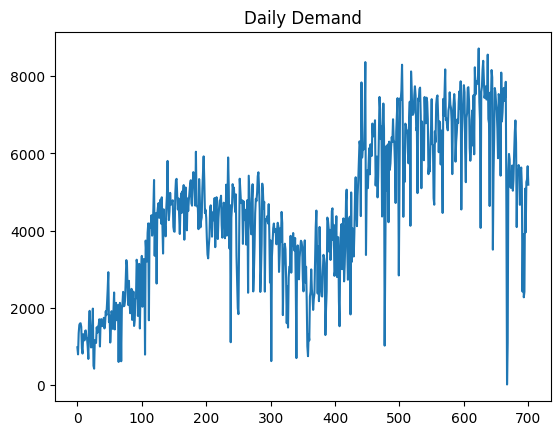

In [57]:
# Daily Closing Price  Plot
df['y'].plot(title = 'Daily Demand')
plt.show()

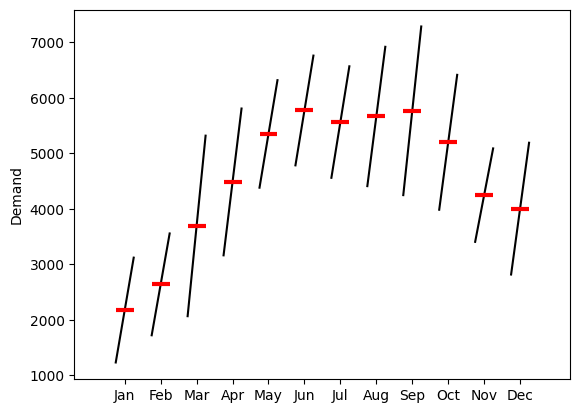

In [58]:
# Plotting the monthly seasonality
month_plot(df_temp['y'].resample('ME').mean(),
           ylabel = 'Demand')
plt.show()

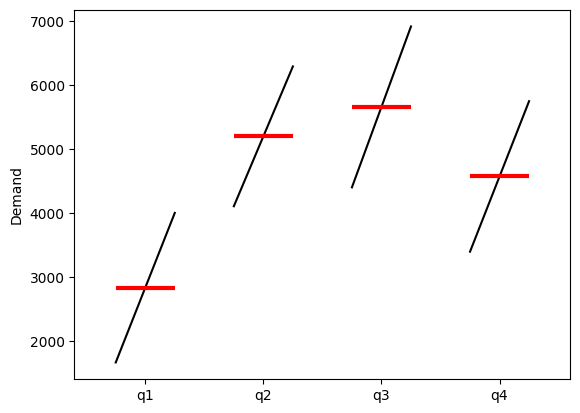

In [59]:
# Plotting the quarterly seasonality
quarter_plot(df_temp['y'].resample('QE').mean(),
           ylabel = 'Demand')
plt.show()

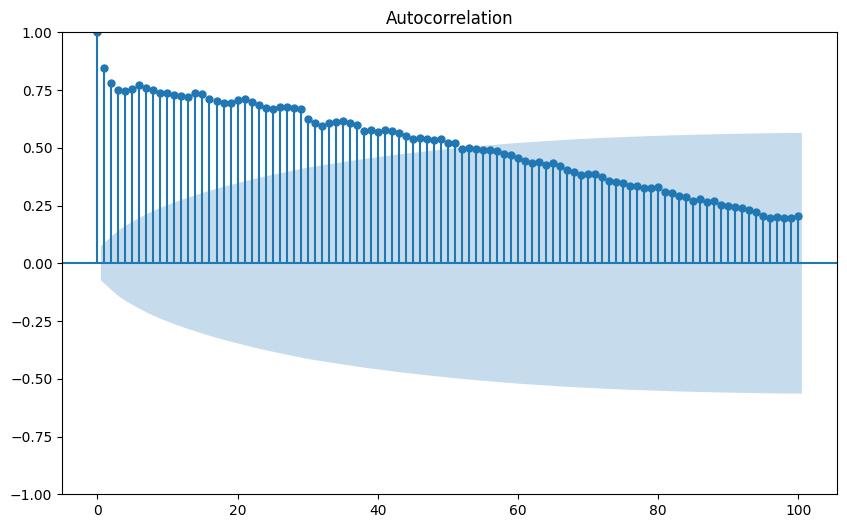

In [60]:
# Plot the autocorrelation (ACF)
fig, ax = plt.subplots(figsize = (10,6))
plot_acf(df_temp['y'], lags = 100, ax = ax)
plt.show()

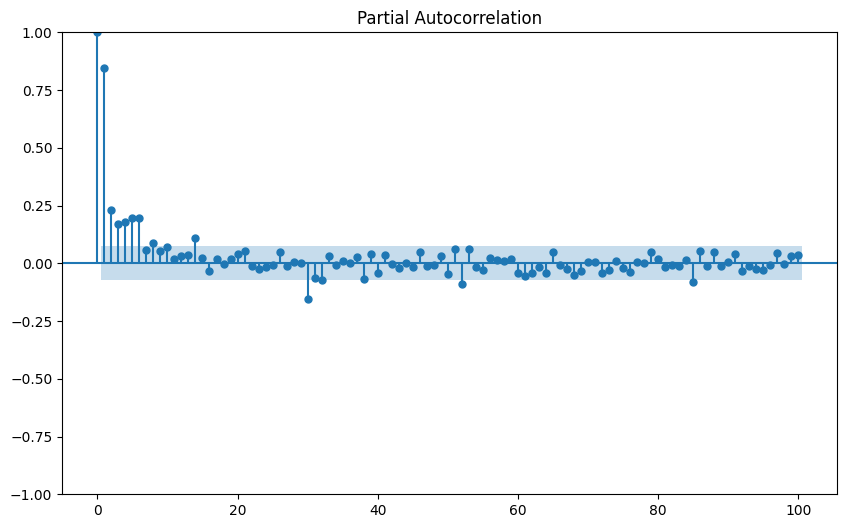

In [61]:
# Plot the partial autocorrelation (PACF)
fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(df_temp['y'], lags = 100, ax = ax)
plt.show()

# Holidays

In [62]:
# Check the holidays in our df
df[df.holiday == 1]

,ds,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3
16,2011-01-17,1,0,2,0.175833,0.176771,0.537500,0.194017,1000,True,False
51,2011-02-21,1,0,2,0.303333,0.284075,0.605000,0.307846,1107,True,False
104,2011-04-15,1,0,1,0.446667,0.441913,0.671250,0.226375,3126,False,False
149,2011-05-30,1,0,1,0.733333,0.671092,0.685000,0.131225,4098,False,False
184,2011-07-04,1,0,2,0.726667,0.665417,0.637917,0.081479,6043,True,False
247,2011-09-05,1,0,2,0.673333,0.625646,0.790417,0.212696,3351,True,False
282,2011-10-10,1,0,1,0.570833,0.542925,0.733750,0.042304,5117,False,False
314,2011-11-11,1,0,1,0.324167,0.306817,0.446250,0.314675,3368,False,False
327,2011-11-24,1,0,1,0.373333,0.372471,0.549167,0.167304,1495,False,False
359,2011-12-26,1,0,1,0.321739,0.315535,0.506957,0.239465,1317,False,False


In [63]:
# Holidays
gen_holidays = pd.DataFrame({'holiday': 'gen_holi',
                            'ds': df[df.holiday == 1].ds,
                             'lower_window': -2, # Effect start 2days before 
                             'upper_window': 2}) # Effect end 2days after 
xmas = pd.DataFrame({'holidays': 'christmas',
                            'ds': pd.to_datetime(['2011-12-24','2012-12-24']),
                             'lower_window': -5, 
                             'upper_window': 3}) 
nye = pd.DataFrame({'holidays': 'new_years',
                            'ds': pd.to_datetime(['2011-12-31','2012-12-31']),
                             'lower_window': -3, 
                             'upper_window': 3}) 
easter = pd.DataFrame({'holidays': 'easter',
                            'ds': pd.to_datetime(['2011-04-24','2012-04-08']),
                             'lower_window': -3, 
                             'upper_window': 3}) 

In [64]:
# Combine all the holidays
holiday = pd.concat([gen_holidays, xmas, nye, easter])
holiday

,holiday,ds,lower_window,upper_window,holidays
16,gen_holi,2011-01-17,-2,2,NaN
51,gen_holi,2011-02-21,-2,2,NaN
104,gen_holi,2011-04-15,-2,2,NaN
149,gen_holi,2011-05-30,-2,2,NaN
184,gen_holi,2011-07-04,-2,2,NaN
247,gen_holi,2011-09-05,-2,2,NaN
282,gen_holi,2011-10-10,-2,2,NaN
314,gen_holi,2011-11-11,-2,2,NaN
327,gen_holi,2011-11-24,-2,2,NaN
359,gen_holi,2011-12-26,-2,2,NaN


# Prophet Model

In [65]:
# Look at df
df.head(1)

,ds,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3
0,2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985,True,False


In [69]:
# Remove any NAs
df = df.dropna()
holiday = holiday.dropna()

In [67]:
from prophet import Prophet

In [72]:
# Building the Prophet model
m = Prophet(yearly_seasonality = True,
            weekly_seasonality = True,
            holidays = holiday, 
            seasonality_mode = "multiplicative",
            seasonality_prior_scale = 10,
            holidays_prior_scale = 10,
            changepoint_prior_scale = 0.05
            )
# We add some variable to help the model
m.add_regressor("workingday")
m.add_regressor("temp")
m.add_regressor("atemp")
m.add_regressor("hum")
m.add_regressor("windspeed")
m.add_regressor("weathersit_2")
m.add_regressor("weathersit_3")
m.fit(df)

16:54:58 - cmdstanpy - INFO - Chain [1] start processing
16:54:58 - cmdstanpy - INFO - Chain [1] done processing
